In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ds = xr.open_dataset("../../../NC/compare.nc")  

In [6]:
def get_diff_values(ds, name, time):
    var_basin  = f"basin_{name}"
    var_region = f"region_{name}"

    da_basin  = ds[var_basin].sel(time=time)
    da_region = ds[var_region].sel(time=time)

    diff = da_region - da_basin
    mask = (da_basin > 0) | (da_region > 0)
    diff_v = diff.where(mask)

    vals = diff_v.values.flatten()
    vals = vals[~np.isnan(vals)]
    return vals


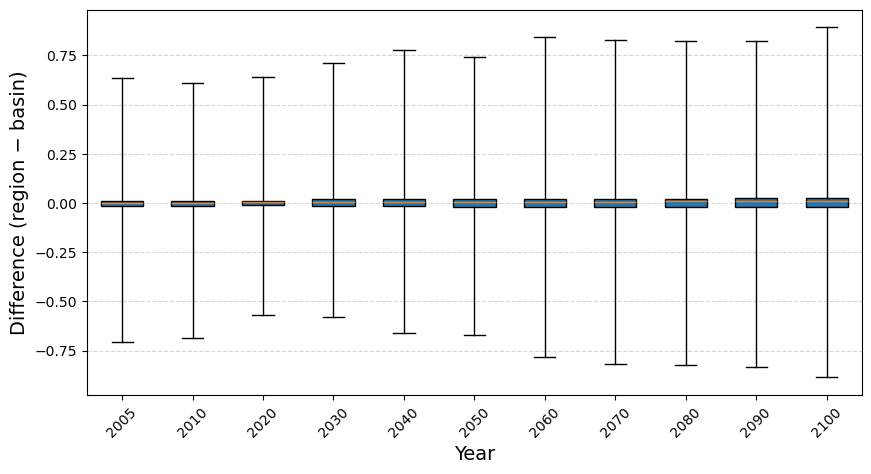

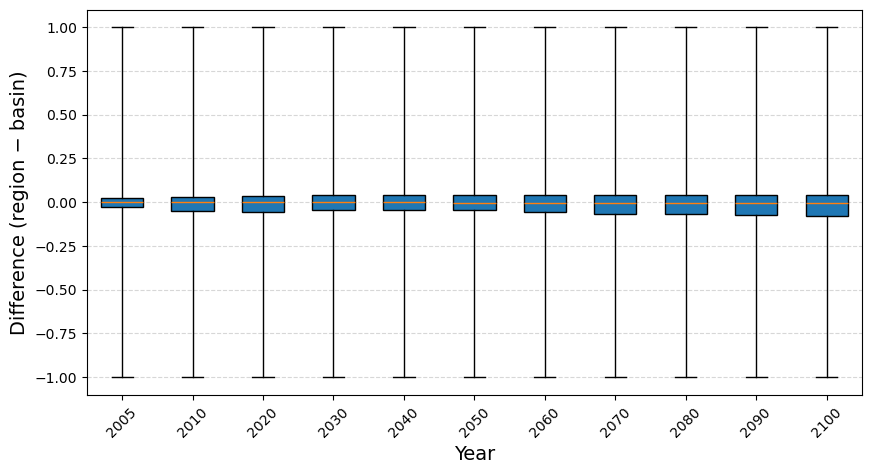

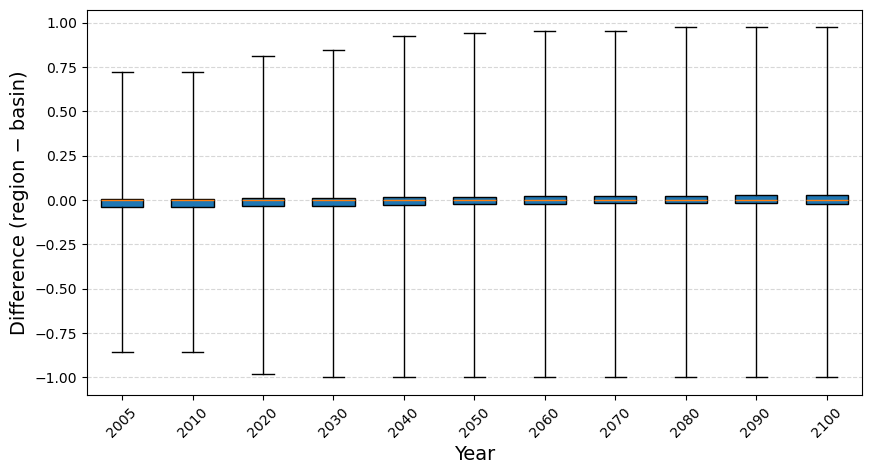

In [7]:
years = list(range(2010, 2101, 10))
years.insert(0, 2005)

names = ["agri", "forest", "grassland"]

for name in names:
    data = []

    for y in years:
        time = f"{y}-01-01"
        vals = get_diff_values(ds, name, time)
        data.append(vals)

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        data,
        widths=0.6,
        patch_artist=True,
        showfliers=False,  # 不画离群点（论文更干净）
        whis=(0, 100)

    )

    plt.xticks(
        ticks=range(1, len(years)+1),
        labels=years,
        rotation=45
    )

    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Difference (region − basin)", fontsize=14)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.savefig(
        f"../../../plot/analysis/{name}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
